# Exercise 4.1: Bet Sizing

Exercises based on Chapter 10 of *Advances in Financial Machine Learning* by Marcos Lopez de Prado.

Aside from deciding when to place orders, an important question in the realm of financial machine learning we need to consider is how to size the bets we place. Two trading strategies executing same-sided (buy/sell) orders at exactly the same times can perform vastly differently, depending on how their bets are sized.

In this exercise we will familiarize ourselves with some methods for determining said bet sizes, as well as some of the other considerations one might take in order to reduce trading costs.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm
from sklearn.mixture import GaussianMixture

from joblib import Parallel, delayed
import seaborn as sns

In this exercise we will once again work with the positions labeled using the triple-barrier method in exercise 2. In order to put all the focus on the order sizing methods, we will utilize the true labels of each position to derive the respective order sizes. When deploying a strategy live these true labels are of course not available. In those circumstances we would instead utilize the labels predicted by our chosen machine learning model.

**NOTE:** When the label is 1 we predict that the upper barrier will be touched first and so our position will be long. In the case where the label is -1 we similarly predict that the lower barrier will be touched first so our position will be short. How we interpret position labeled 0 is up to us, but in this exercise we will ignore them. This corresponds to a strategy where we elect to not undertake positions where the horizontal barrier is predicted to be touched first.

In [5]:
df = pd.read_csv('./data/labeled_positions.csv', index_col=0)
df['position_start'] = pd.to_datetime(df['position_start'], format='ISO8601')
df['position_end'] = pd.to_datetime(df['position_end'], format='ISO8601')


df.drop(['profit_return_lim', 'loss_return_lim', 'touch_time'], axis=1, inplace=True)

# Load entire dollar bar dataset
df2 = pd.read_csv('./data/dollar_bars.csv')
df2['datetime'] = pd.to_datetime(df2['datetime'])

# Use partial data if running the code is taking too long.
# You migt also use partial data just to make the plots furthetr down more legible.

#df = df[df['position_start'] < '2011'] 

df.head()

,position_start,position_end,label
0,2010-01-04 18:26:23,2010-01-05 18:59:52,1
1,2010-01-04 18:52:10,2010-01-05 18:59:52,1
2,2010-01-04 21:21:08,2010-01-05 22:01:33,-1
3,2010-01-04 22:43:50,2010-01-06 00:08:46,-1
4,2010-01-05 00:14:59,2010-01-06 01:14:27,-1


Both of the sizing methods we will be exploring we make use of the number of concurrent long bets $c_{l,t}$ and short bets $c_{s,t}$ that are active at time $t$. The function below will take as input a dataframe of positions and a label, outputting the number of active positions with said label at each timestamp.

In [6]:
def get_concurrent_bets(df, label):
    start = (df[df['label'] == label]
             [['position_start', 'label']]
             .rename(columns={'position_start': 'timestamp'})
             .assign(label=1))
    
    end = (df[df['label'] == label]
           [['position_end', 'label']]
           .rename(columns={'position_end': 'timestamp'})
           .assign(label=-1)
           .groupby('timestamp')
           .sum()
           .reset_index())
    
    return (pd.concat([start, end])
            .sort_values('timestamp')
            .reset_index(drop=True)
            .assign(active_positions=lambda x: x['label'].cumsum())
            [['timestamp', 'active_positions']])

We will then find the series of concurrent bets for both long and short positions. Running this with the whole data could overwhelm your computer.

In [7]:
def plot_positions(df, position_type):
    plt.figure(figsize=(12, 6))
    
    # Convert timestamp to numeric for faster plotting
    x = pd.to_datetime(df['timestamp']).astype(int) / 10**9
    y = df['active_positions']
    
    # Use plot instead of lineplot for faster rendering
    plt.plot(x, y, linewidth=1)
    
    plt.title(f'Active {position_type.capitalize()} Positions Over Time')
    plt.xlabel('Timestamp')
    plt.ylabel(f'Active {position_type} positions')
    
    # Format x-axis ticks
    plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: pd.to_datetime(x, unit='s').strftime('%Y-%m-%d')))
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

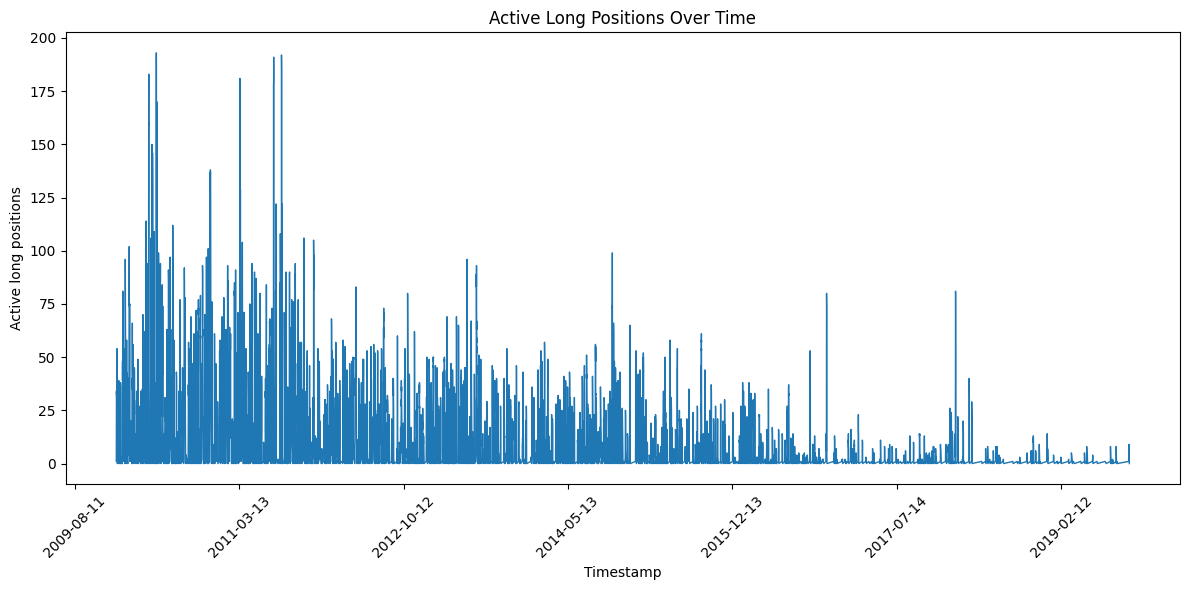

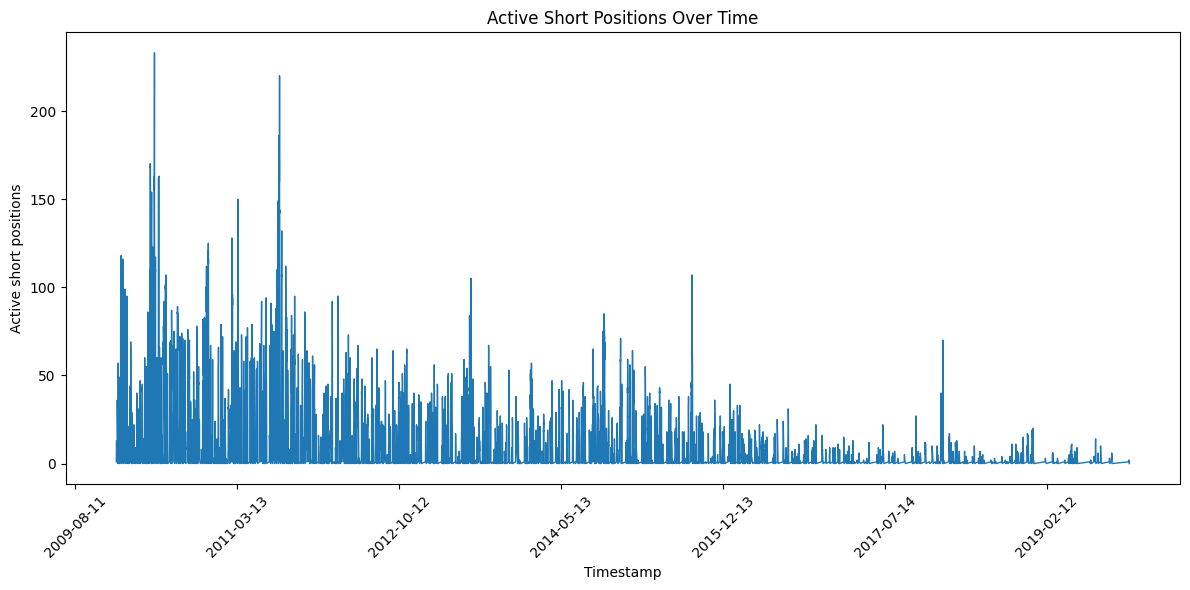

Summary of Long Positions:
          timestamp  active_positions
2010-01-04 18:26:23                 1
2010-01-04 18:52:10                 2
2010-01-05 02:21:45                 3
2010-01-05 02:43:02                 4
2010-01-05 02:47:28                 5


In [8]:
def process_labels(df, labels):
    results = Parallel(n_jobs=-1)(delayed(get_concurrent_bets)(df, label) for label in labels)
    return dict(zip(labels, results))


labels = [1, -1]  
result_dict = process_labels(df, labels)

df_long = result_dict[1]
df_short = result_dict[-1]

plot_positions(df_long, 'long')
plot_positions(df_short, 'short')

print("Summary of Long Positions:")
print(df_long.head().to_string(index=False))


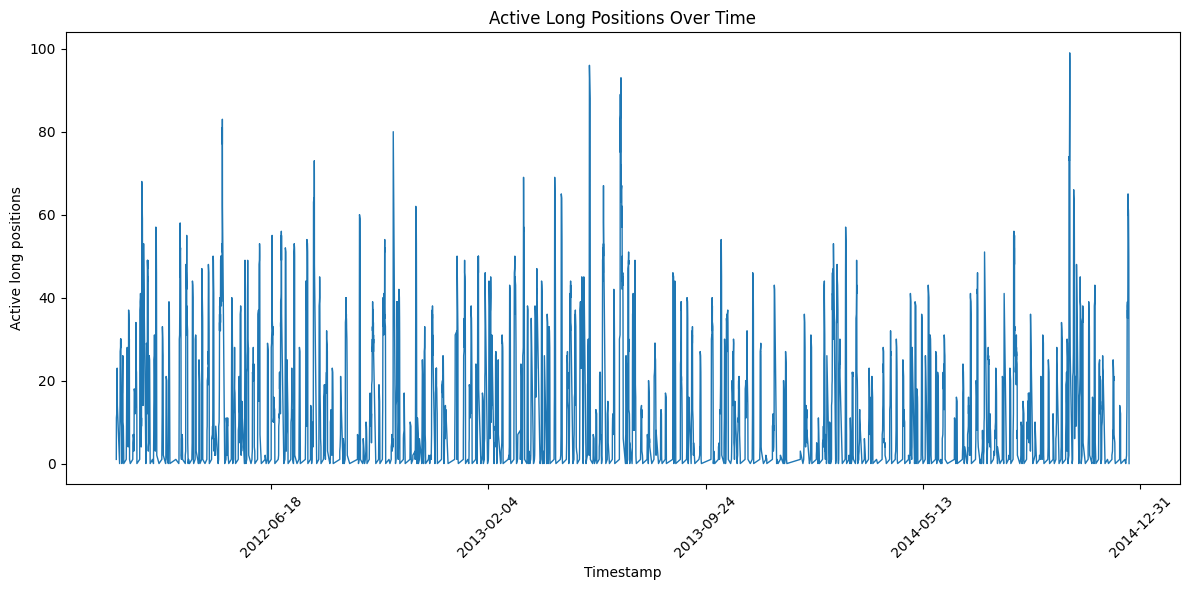

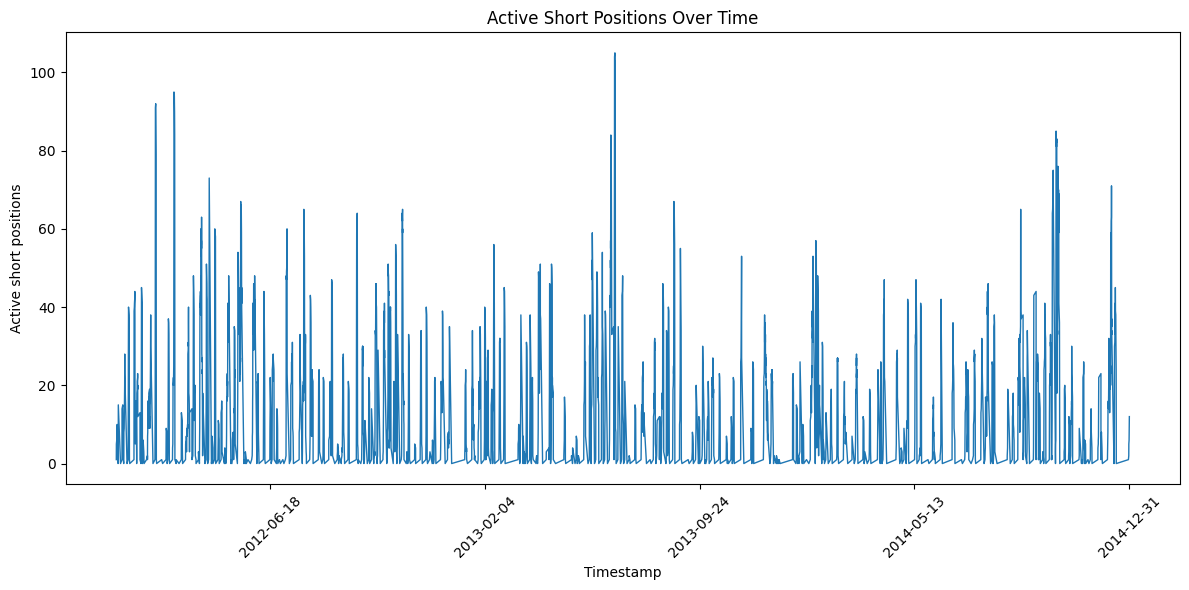

In [9]:
plot_positions(df_long[(df_long['timestamp'].dt.year >= 2012) &
         (df_long['timestamp'].dt.year <= 2014)],'long')
plot_positions(df_short[(df_short['timestamp'].dt.year >= 2012) &
         (df_short['timestamp'].dt.year <= 2014)], 'short')

Let's then combine both dataframes into one. Since we also only care about bet sized when positions are undertaken, we will drop rows that correspond to timestamps when a position ends rather than begins.

In [10]:
df_all = df_long.join(df_short.set_index('timestamp'), on='timestamp', how='outer', lsuffix='_l', rsuffix='_s')
df_all = df_all.rename(columns={'active_positions_l': 'active_long', 'active_positions_s':'active_short'})
df_all = df_all.sort_values(by=['timestamp'])
df_all.iloc[0] = df_all.iloc[0].fillna(0)
df_all = df_all.ffill()
df_all = df_all.reset_index(drop=True)
df_all.head()

,timestamp,active_long,active_short
0,2010-01-04 18:26:23,1.0,0.0
1,2010-01-04 18:52:10,2.0,0.0
2,2010-01-04 21:21:08,2.0,1.0
3,2010-01-04 22:43:50,2.0,2.0
4,2010-01-05 00:14:59,2.0,3.0


In [11]:
df_all = df_all[df_all['timestamp'].isin(df['position_start'])]
df_all.head()

,timestamp,active_long,active_short
0,2010-01-04 18:26:23,1.0,0.0
1,2010-01-04 18:52:10,2.0,0.0
2,2010-01-04 21:21:08,2.0,1.0
3,2010-01-04 22:43:50,2.0,2.0
4,2010-01-05 00:14:59,2.0,3.0


## Sizing through a Gaussian mixture

The end goal with bet sizing is to make sure we reserve some budget for the possibility that the signal gets stronger. Intuitively, we would like to place a bet of magnitue 0.9 when we predict that the probability of getting an even stronger signal is 0.1 (or 0.6 when the probability is 0.4, and so on).

A way to achieve this is to first calculate the difference between long and short bets $c_{l,t} - c_{s,t}$ and to size our bets as

$m_t=\begin{cases}\frac{F\left[c_t\right]-F\left[0\right]}{1-F\left[0\right]}&c_t\geq0\\\frac{F\left[c_t\right]-F\left[0\right]}{F\left[0\right]}&c_t<0\end{cases}$,

where $F\left[x\right]$ is the cumulative distribution function (CDF) of a 2-component Gaussian mixture we fit to the observed distribution of $c_t$.


For the mathematically curious the links below will provide a more in-depth explanation of the method and the prerequisite knowledge.

https://www.researchgate.net/publication/262057544_A_mixture_of_Gaussians_approach_to_mathematical_portfolio_oversight_the_EF3M_algorithm

https://en.wikipedia.org/wiki/Mixture_model

All this being said, let's start by calculation the series of bet balances.

In [12]:
df_all['balance'] = df_all['active_long'] - df_all['active_short']
df_all.head()

,timestamp,active_long,active_short,balance
0,2010-01-04 18:26:23,1.0,0.0,1.0
1,2010-01-04 18:52:10,2.0,0.0,2.0
2,2010-01-04 21:21:08,2.0,1.0,1.0
3,2010-01-04 22:43:50,2.0,2.0,0.0
4,2010-01-05 00:14:59,2.0,3.0,-1.0


We will then fit the 2-components Gaussian mixture and use it to calculate the bet sizes using the formula above. The two blocks below fit the mixture and define functions for calculating the bet size.

In [13]:
x = df_all['balance'].values.reshape(-1, 1)
gm = GaussianMixture(n_components=2, random_state=0).fit(x)

In [14]:
def gm_cdf(x, gm):
    prob = 0
    for weight, mean, var in zip(
        gm.weights_.flatten(),
        gm.means_.flatten(),
        gm.covariances_.flatten()):

        prob += weight * norm.cdf(x, loc=mean, scale=np.sqrt(var))
    return prob

def bet_size(c, gm):
    if c >= 0:
        return (gm_cdf(c, gm) - gm_cdf(0, gm)) / (1 - gm_cdf(0, gm))
    else:
        return (gm_cdf(c, gm) - gm_cdf(0, gm)) / gm_cdf(0, gm)

We can then calculate the bet size for each position, as well as plot the series of bet sizes.

In [15]:
# Parallel processing of bet_size function
df_all['bet_gm'] = Parallel(n_jobs=-1)(
    delayed(bet_size)(balance, gm) for balance in df_all['balance']
)
df_all.head()

,timestamp,active_long,active_short,balance,bet_gm
0,2010-01-04 18:26:23,1.0,0.0,1.0,0.021430
1,2010-01-04 18:52:10,2.0,0.0,2.0,0.042852
2,2010-01-04 21:21:08,2.0,1.0,1.0,0.021430
3,2010-01-04 22:43:50,2.0,2.0,0.0,0.000000
4,2010-01-05 00:14:59,2.0,3.0,-1.0,-0.019658


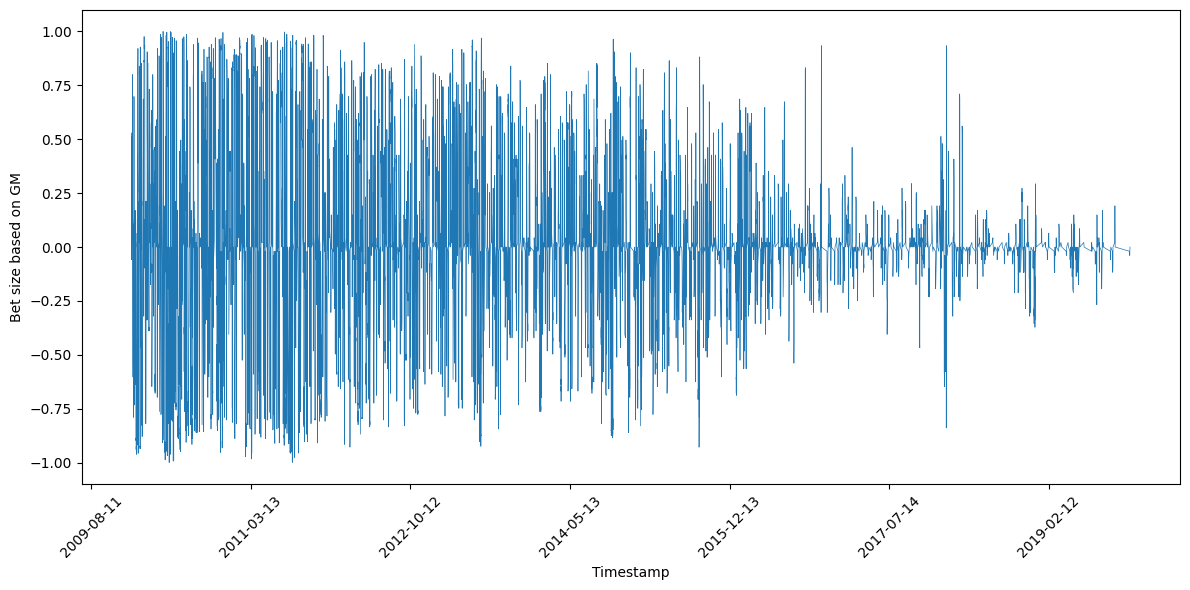

In [16]:
plt.figure(figsize=(12, 6))
    
x = pd.to_datetime(df_all['timestamp']).astype(int) / 10**9
y = df_all['bet_gm']
    
# Use plot instead of lineplot for faster rendering
plt.plot(x, y, linewidth=0.5)
    
plt.xlabel('Timestamp')
plt.ylabel(f'Bet size based on GM')
    
# Format x-axis ticks
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: pd.to_datetime(x, unit='s').strftime('%Y-%m-%d')))
plt.xticks(rotation=45)
    
plt.tight_layout()
plt.show()

## Sizing through budgeting

Another, relatively more simple approach is one based on so-called "budgeting". In this approach we calculate the maximum number of observed long bets, $\max_i{c_{l,i}}$, and short bets, $\max_i{c_{s,i}}$. The bet sizes are then calculated using the formula

$m_t=\frac{c_{l,t}}{\max_i{c_{l,i}}}-\frac{c_{s,t}}{\max_i{c_{s,i}}}$.

The intuition is that the largest bets are only placed when the largest concurrent signasl are achieved. The code below implements this approach and plots the time series and histograms of bet sizes calculated using both approaches discussed so far.

In [17]:
long_max = df_all['active_long'].max()
short_max = df_all['active_short'].max()
df_all['bet_bud'] = df_all['active_long'] / long_max - df_all['active_short'] / short_max
df_all.head()

,timestamp,active_long,active_short,balance,bet_gm,bet_bud
0,2010-01-04 18:26:23,1.0,0.0,1.0,0.021430,0.005181
1,2010-01-04 18:52:10,2.0,0.0,2.0,0.042852,0.010363
2,2010-01-04 21:21:08,2.0,1.0,1.0,0.021430,0.006071
3,2010-01-04 22:43:50,2.0,2.0,0.0,0.000000,0.001779
4,2010-01-05 00:14:59,2.0,3.0,-1.0,-0.019658,-0.002513


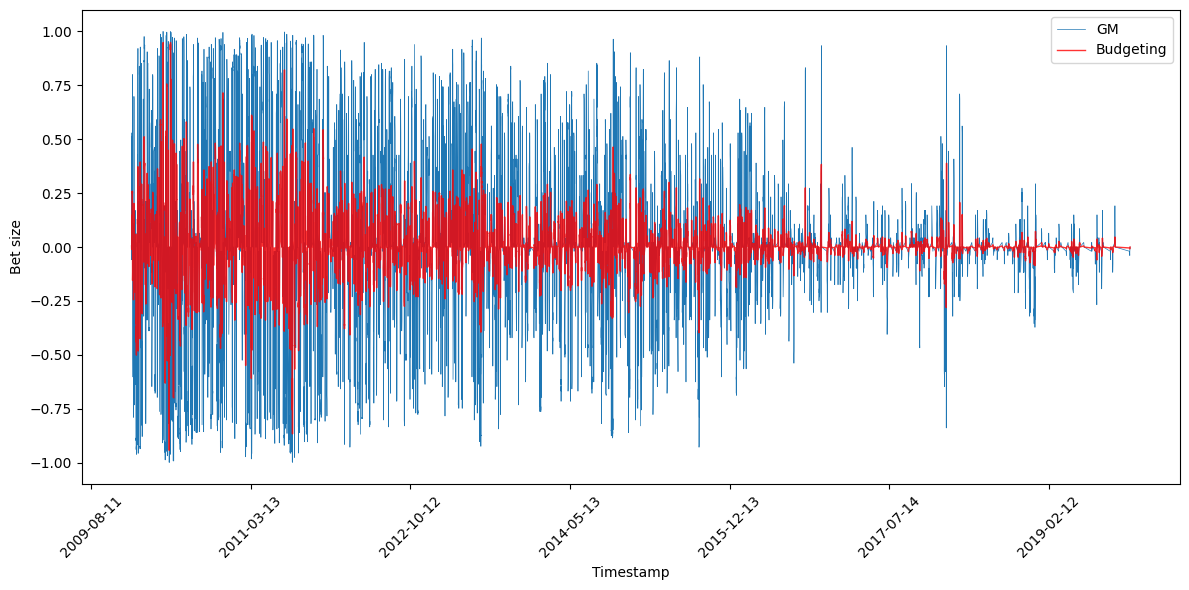

In [18]:
plt.figure(figsize=(12, 6))
    
x = pd.to_datetime(df_all['timestamp']).astype(int) / 10**9
y = df_all['bet_gm']
z = df_all['bet_bud']
    
# Use plot instead of lineplot for faster rendering
plt.plot(x, y, linewidth=0.5, label='GM')
plt.plot(x, z, linewidth=1.0, color='r', label='Budgeting', alpha=0.8)
    
plt.xlabel('Timestamp')
plt.ylabel(f'Bet size')
    
# Format x-axis ticks
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: pd.to_datetime(x, unit='s').strftime('%Y-%m-%d')))
plt.xticks(rotation=45)
plt.legend()
    
plt.tight_layout()
plt.show()

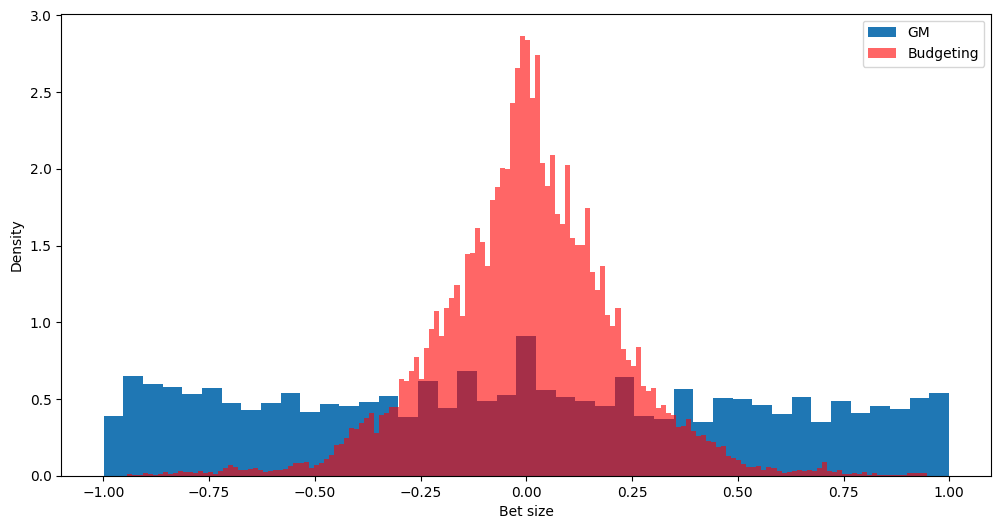

In [19]:
plt.figure(figsize=(12, 6))

plt.hist(y, bins='auto', density=True, label='GM')
plt.hist(z, bins='auto', density=True, color='r', label='Budgeting', alpha=0.6)
plt.xlabel('Bet size')
plt.ylabel('Density')
plt.legend()
plt.show()

## <u>Question 1</u>

How do the two sizing methods differ in terms of their bet sizes? How would the methods used explain this difference? What reasons might you have for preferring one over the other?

## Averaging bet sizes

As new information comes in we might want to average the bet sizes across all active bets. This will give us a new bet, describing the relevant information available to us at that time.

The code below implements this by first rejoining the data with the position end times and then for each timestamp calculating the average bet size across active bets. The bet sizes calculated using the budgeting approach are used by default, but you are encouraged to modify the code to explore other cases.

In [20]:
df_all = df_all[['timestamp', 'bet_gm', 'bet_bud']]
df_all = df_all.join(df[['position_start', 'position_end']].set_index('position_start'), on='timestamp', how='left')
df_all.head()

,timestamp,bet_gm,bet_bud,position_end
0,2010-01-04 18:26:23,0.021430,0.005181,2010-01-05 18:59:52
1,2010-01-04 18:52:10,0.042852,0.010363,2010-01-05 18:59:52
2,2010-01-04 21:21:08,0.021430,0.006071,2010-01-05 22:01:33
3,2010-01-04 22:43:50,0.000000,0.001779,2010-01-06 00:08:46
4,2010-01-05 00:14:59,-0.019658,-0.002513,2010-01-06 01:14:27


In [21]:
def avg_bets(row, df, bet):
    timestamp = row['timestamp']
    active = (df['timestamp'] <= timestamp) & (df['position_end'] > timestamp)
    active_df = df[active]
    return active_df[bet].mean()

In [22]:
df_all['bet_avg'] = df_all.apply(lambda x: avg_bets(x, df_all, 'bet_bud'), axis=1)
df_all.head()

,timestamp,bet_gm,bet_bud,position_end,bet_avg
0,2010-01-04 18:26:23,0.021430,0.005181,2010-01-05 18:59:52,0.005181
1,2010-01-04 18:52:10,0.042852,0.010363,2010-01-05 18:59:52,0.007772
2,2010-01-04 21:21:08,0.021430,0.006071,2010-01-05 22:01:33,0.007205
3,2010-01-04 22:43:50,0.000000,0.001779,2010-01-06 00:08:46,0.005848
4,2010-01-05 00:14:59,-0.019658,-0.002513,2010-01-06 01:14:27,0.004176


Having calculated the averaged bets, we can plot them together with the non-averaged bets to perform a comparison.

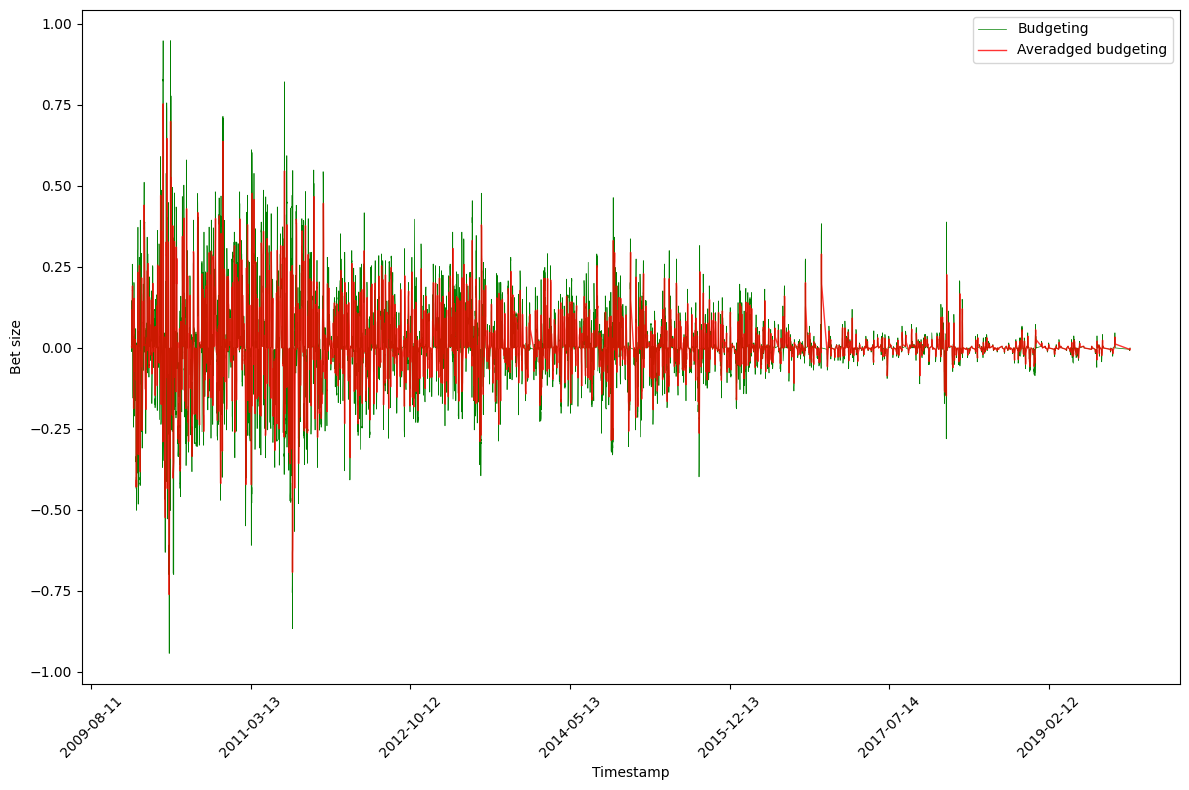

In [23]:
plt.figure(figsize=(12, 8))
    
q = df_all['bet_avg']
    
# Use plot instead of lineplot for faster rendering
plt.plot(x, z, linewidth=0.5, color='g', label='Budgeting')
plt.plot(x, q, linewidth=1.0, color='r', label='Averadged budgeting', alpha=0.8)
    
plt.xlabel('Timestamp')
plt.ylabel(f'Bet size')
    
# Format x-axis ticks
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: pd.to_datetime(x, unit='s').strftime('%Y-%m-%d')))
plt.xticks(rotation=45)
plt.legend()
    
plt.tight_layout()
plt.show()

## <u>Question 2</u>

What other approaches might we undertake in regards to our previous positions as new signals emerge? Why might averaging bets be preferable?

**HINT:** Think about costs.

## Discretizing bet sizes

Yet another approach we might take to stabilize our trades is to discretize the bet sizes. The code below implements this on the already averages bet sizes. You are encouraged to play around with the degree of discretization and see how the results are affected.

In [24]:
disc_deg = 0.05
df_all['bet_disc'] = np.round(df_all['bet_avg'] / disc_deg) * disc_deg

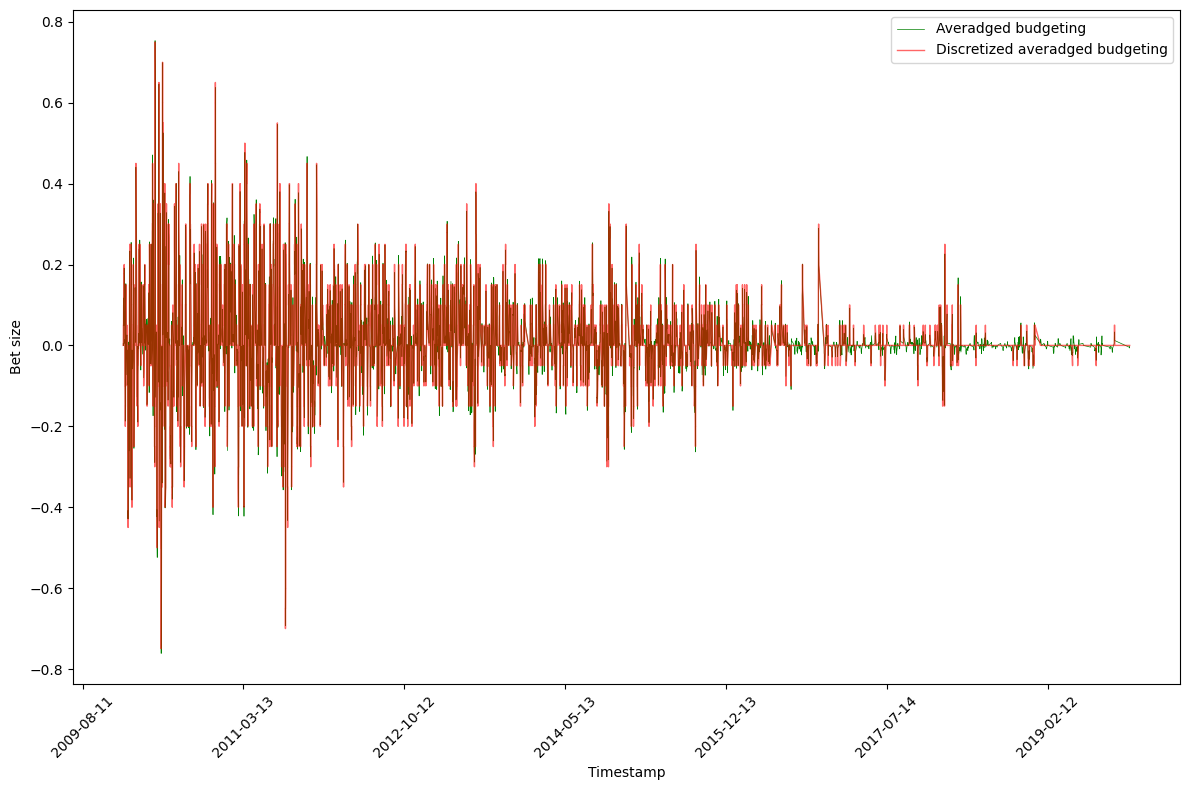

In [25]:
plt.figure(figsize=(12, 8))
    
p = df_all['bet_disc']
    
# Use plot instead of lineplot for faster rendering
plt.plot(x, q, linewidth=0.5, color='g', label='Averadged budgeting')
plt.plot(x, p, linewidth=1.0, color='r', label='Discretized averadged budgeting', alpha=0.6)
    
plt.xlabel('Timestamp')
plt.ylabel(f'Bet size')
    
# Format x-axis ticks
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: pd.to_datetime(x, unit='s').strftime('%Y-%m-%d')))
plt.xticks(rotation=45)
plt.legend()
    
plt.tight_layout()
plt.show()

## <u>Question 3</u>

How does discretization address the problem averaging aimed to address? What are the trade offs between different degrees of discretization and how might you decide a good level for your strategy?